In [1]:
%pip install geopandas folium

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from energy_processor import load_combined_gdf, process_energy_csv

# Load the already-combined NYCHA+PLUTO CSV as a GeoDataFrame
combined_gdf = load_combined_gdf('../cleaned_data/combined_nychares_pluto.csv')

combined_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2961 entries, 0 to 2960
Data columns (total 93 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   development                        2961 non-null   object  
 1   tds_#                              2961 non-null   int64   
 2   building_#                         2961 non-null   object  
 3   stairhall#                         2961 non-null   int64   
 4   borough_nycha                      2961 non-null   object  
 5   house_#                            2961 non-null   object  
 6   street                             2961 non-null   object  
 7   address_nycha                      2961 non-null   object  
 8   city                               2961 non-null   object  
 9   state                              2961 non-null   object  
 10  zip_code                           2961 non-null   object  
 11  bin                                

In [3]:
print(f"Combined rows: {len(combined_gdf)}")
print(f"Columns: {combined_gdf.columns.tolist()}")

Combined rows: 2961
Columns: ['development', 'tds_#', 'building_#', 'stairhall#', 'borough_nycha', 'house_#', 'street', 'address_nycha', 'city', 'state', 'zip_code', 'bin', 'block', 'lot', 'BBL', 'census_tract_(2020)', 'neighborhood_tabulation_area_code', 'neighborhood_tabulation_area_name', 'community_district', 'city_council_district', 'state_assembly_district', 'state_senate_district', 'us_congressional_district', 'privately_managed', 'latitude_nycha', 'longitude_nycha', 'geometry', 'borough_pluto', 'tax_block', 'tax_lot', 'census_tract_2010', 'cb2010', 'council_district', 'postcode', 'policeprct', 'healtharea', 'address_pluto', 'zonedist1', 'zonedist2', 'zonedist3', 'zonedist4', 'ltdheight', 'bldgclass', 'landuse', 'easements', 'ownertype', 'ownername', 'lotarea', 'bldgarea', 'resarea', 'garagearea', 'strgearea', 'otherarea', 'areasource', 'numbldgs', 'numfloors', 'unitsres', 'unitstotal', 'lotfront', 'lotdepth', 'bldgfront', 'bldgdepth', 'proxcode', 'irrlotcode', 'lottype', 'asses

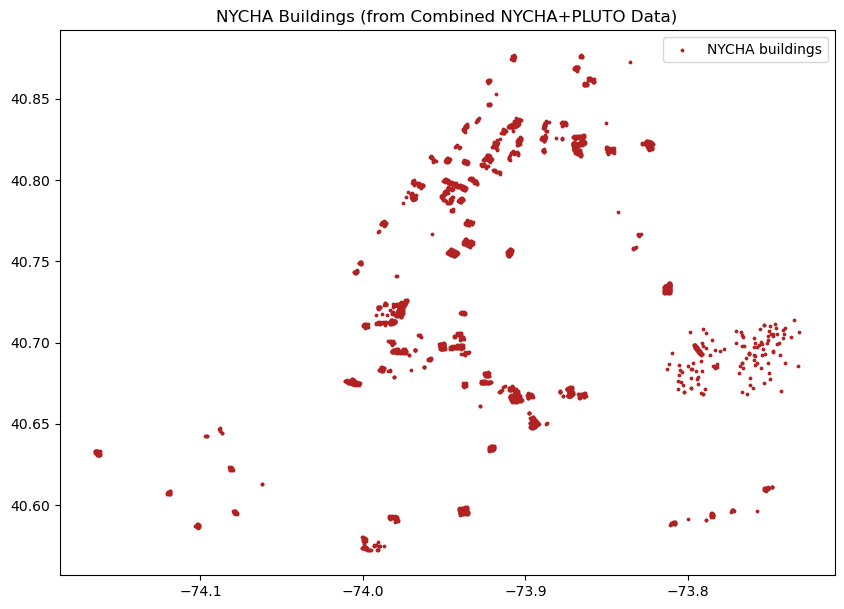

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
combined_gdf.plot(ax=ax, color='firebrick', markersize=3, label='NYCHA buildings')
ax.set_title('NYCHA Buildings (from Combined NYCHA+PLUTO Data)')
ax.legend()
plt.show()

In [5]:
# Check a sample of rows
combined_gdf[['BBL', 'bbl', 'development', 'landuse', 'yearbuilt']].sample(10)

,BBL,bbl,development,landuse,yearbuilt
323,3035610001,3.035610e+09,BROWNSVILLE,3.0,1975.0
1248,1016840001,1.016840e+09,JEFFERSON,3.0,1959.0
2327,3074051001,3.074051e+09,SHEEPSHEAD BAY,3.0,1950.0
1378,1017570001,1.017570e+09,LINCOLN,3.0,1947.0
2785,1003560001,1.003560e+09,WALD,3.0,1950.0
1237,2024160001,2.024160e+09,JACKSON,3.0,1960.0
914,4110120043,4.110120e+09,FHA REPOSSESSED HOUSES (GROUP V),1.0,1920.0
1886,4067920030,4.067920e+09,POMONOK,3.0,1952.0
2367,2037230001,2.037230e+09,SOTOMAYOR HOUSES,3.0,1953.0
1981,4004700100,4.004700e+09,QUEENSBRIDGE NORTH,4.0,1939.0


In [6]:
import folium
from folium.plugins import MarkerCluster

# Center map on NYC
m = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# Add NYCHA points as clustered markers
marker_cluster = MarkerCluster().add_to(m)

for _, row in combined_gdf.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=f"BBL: {row['BBL']}<br>Development: {row.get('development', 'N/A')}",
    ).add_to(marker_cluster)

m

In [7]:
# Process heating gas data with the reusable function
final_gdf, heating_gas_cost_df_cleaned = process_energy_csv(
    csv_path='../raw_data/Heating_Gas_Consumption_And_Cost_(2010_-__Sep_2025)_20260314.csv',
    consumption_col='Consumption (Therms)',
    combined_gdf=combined_gdf,
)
print(f"Rows with missing consumption: {final_gdf['consumption_(therms)'].isna().sum()}")
print(final_gdf[['development', 'tds_#', 'consumption_(therms)']].head(10))

/var/folders/wl/z660nksx5sgdsrv2k5v3n27m0000gn/T/ipykernel_941/1688574124.py:3: DtypeWarning: Columns (7,16) have mixed types. Specify dtype option on import or set low_memory=False.
  heating_gas_cost_df = pd.read_csv('../raw_data/Heating_Gas_Consumption_And_Cost_(2010_-__Sep_2025)_20260314.csv')


,development_name,borough,tds_#,funding_source,vendor_name,revenue_month,service_start_date,service_end_date,#_days,meter_number,current_charges,consumption_(therms),es_commodity,underlying_utility
0,SOTOMAYOR HOUSES,BRONX,67.0,FEDERAL,CONSOLIDATED EDISON COMPANY OF NY,2025-09,08/21/2025,09/22/2025,32,004212358,"$1,280.33",0.00,UTILITY GAS,NaN
1,QUEENSBRIDGE SOUTH,QUEENS,5.0,FEDERAL,CONSOLIDATED EDISON COMPANY OF NY,2025-09,08/21/2025,09/22/2025,32,002988768,"$15,540.22",12351.00,UTILITY GAS,ConEd
2,ALLEN STREET,MANHATTAN,265.0,FEDERAL,CONSOLIDATED EDISON COMPANY OF NY,2025-09,08/21/2025,09/22/2025,32,003299919,$53.27,0.00,UTILITY GAS,ConEd
3,EAST 165TH STREET-BRYANT AVENUE,BRONX,304.0,FEDERAL,NRG Business Marketing (32179),2025-09,08/22/2025,09/22/2025,31,47726810006,$425.84,576.00,BROKERED GAS,ConEd
4,HOLMES TOWERS,MANHATTAN,159.0,FEDERAL,NRG Business Marketing (32179),2025-09,08/22/2025,09/22/2025,31,81471700005,"$16,738.49",22641.00,BROKERED GAS,ConEd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248910,WOODSIDE,QUEENS,33.0,FEDERAL,HESS CORPORATION (905243) - 2,2010-01,12/30/2009,01/28/2010,29,692010600,"$207,005.53",211512.98,BROKERED GAS,NatGrid NYC
248911,WOODSON,BROOKLYN,182.0,FEDERAL,National Grid NYC,2010-01,12/29/2009,01/28/2010,30,6307418,"$14,846.91",51178.00,UTILITY GAS,NatGrid NYC
248912,WOODSON,BROOKLYN,182.0,FEDERAL,HESS CORPORATION (905243) - 2,2010-01,12/30/2009,01/28/2010,29,548925110,"$50,112.25",51203.42,BROKERED GAS,NatGrid NYC
248913,WYCKOFF GARDENS,BROOKLYN,163.0,FEDERAL,National Grid NYC,2010-01,12/29/2009,01/28/2010,30,811385,"$24,188.16",83640.00,UTILITY GAS,NatGrid NYC


In [13]:
heating_gas_cost_df_cleaned.columns.tolist()

['development_name',
 'borough',
 'account_name',
 'location',
 'meter_amr',
 'meter_scope',
 'tds_#',
 'edp',
 'rc_code',
 'funding_source',
 'amp_#',
 'vendor_name',
 'umis_bill_id',
 'revenue_month',
 'service_start_date',
 'service_end_date',
 '#_days',
 'meter_number',
 'estimated',
 'current_charges',
 'rate_class',
 'bill_analyzed',
 'consumption_(therms)',
 'es_commodity',
 'underlying_utility']

In [14]:
# Generate top 10 developments by aggregate heating gas consumption

final_gdf.groupby('development')['consumption_(therms)'].sum().sort_values(ascending=False).head(10)

development
POMONOK                 8.850352e+09
BREUKELEN               6.644479e+09
CLASON POINT GARDENS    3.490026e+09
RAVENSWOOD              2.919529e+09
INGERSOLL               2.382778e+09
MARCY                   2.334352e+09
QUEENSBRIDGE NORTH      2.176048e+09
RED HOOK EAST           2.148286e+09
THROGGS NECK            2.110624e+09
WOODSIDE                2.085635e+09
Name: consumption_(therms), dtype: float64

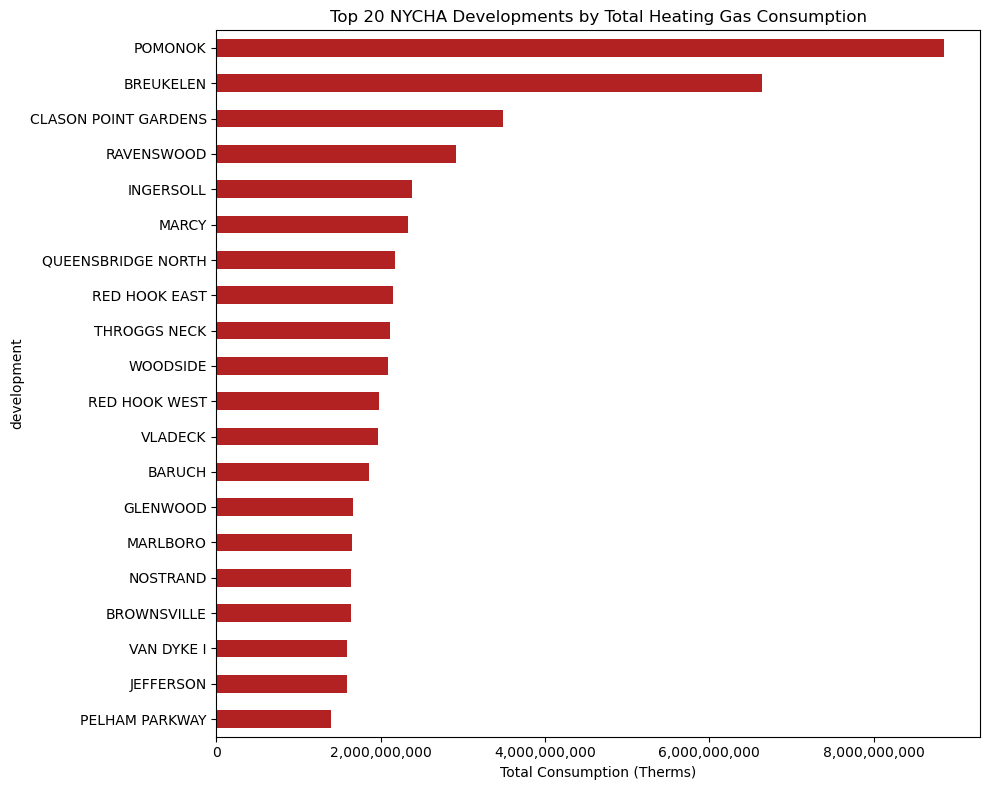

In [15]:
# Top 20 developments by total heating gas consumption

import matplotlib.pyplot as plt

top20_total = (
    final_gdf.groupby('development')['consumption_(therms)']
    .sum()
    .sort_values(ascending=True)
    .tail(20)
)

fig, ax = plt.subplots(figsize=(10, 8))
top20_total.plot(kind='barh', ax=ax, color='firebrick')
ax.set_xlabel('Total Consumption (Therms)')
ax.set_title('Top 20 NYCHA Developments by Total Heating Gas Consumption')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

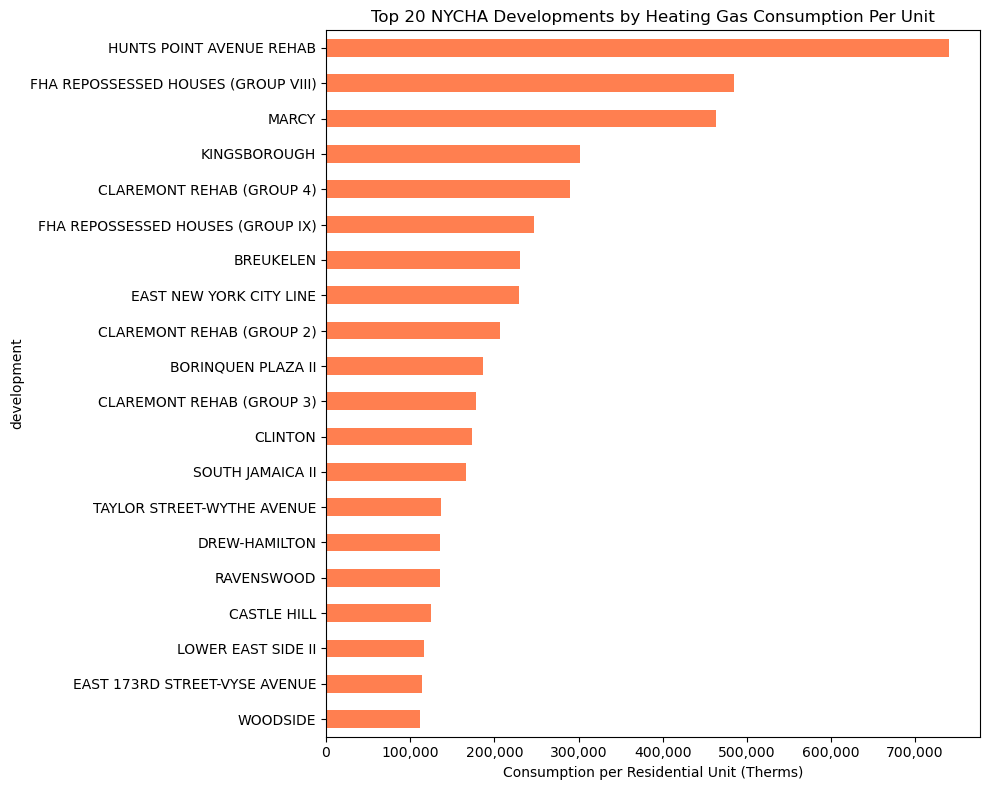

In [16]:
# Top 20 developments by heating gas consumption per unit

final_gdf['consumption_(therms)'] = pd.to_numeric(final_gdf['consumption_(therms)'], errors='coerce')
final_gdf['unitsres'] = pd.to_numeric(final_gdf['unitsres'], errors='coerce')

final_gdf['consumption_per_unit'] = final_gdf['consumption_(therms)'] / final_gdf['unitsres']

top20_perunit = (
    final_gdf.dropna(subset=['development', 'consumption_per_unit'])
    .groupby('development')['consumption_per_unit']
    .mean()
    .sort_values(ascending=True)
    .tail(20)
)

fig, ax = plt.subplots(figsize=(10, 8))
top20_perunit.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Consumption per Residential Unit (Therms)')
ax.set_title('Top 20 NYCHA Developments by Heating Gas Consumption Per Unit')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

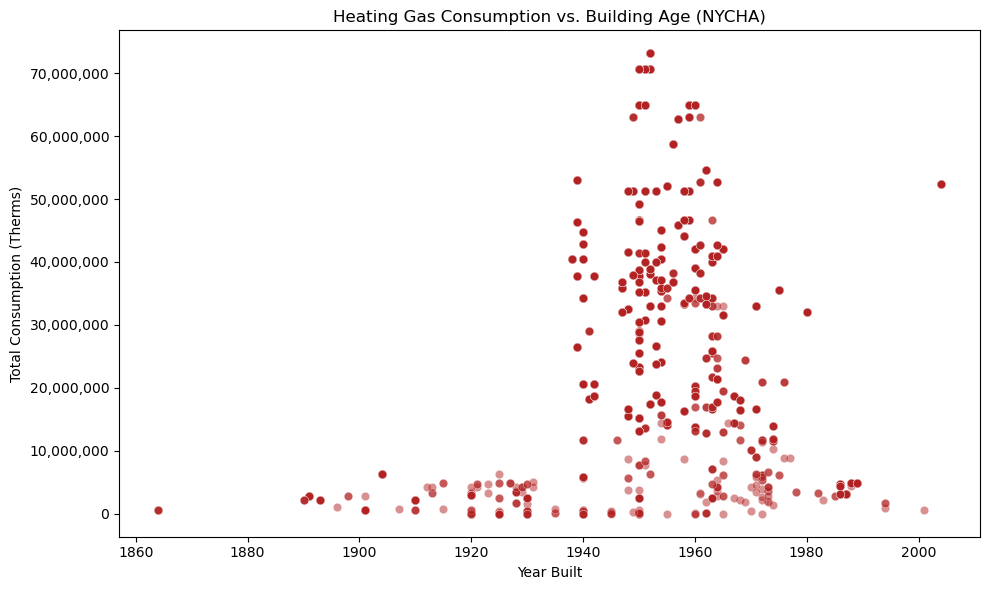

In [17]:
# Heating gas consumption vs building age

fig, ax = plt.subplots(figsize=(10, 6))

scatter_df = final_gdf.dropna(subset=['yearbuilt', 'consumption_(therms)'])
scatter_df = scatter_df[scatter_df['yearbuilt'] > 0]  # drop placeholder 0s

ax.scatter(scatter_df['yearbuilt'], scatter_df['consumption_(therms)'],
           alpha=0.5, color='firebrick', edgecolors='white', linewidth=0.3)

ax.set_xlabel('Year Built')
ax.set_ylabel('Total Consumption (Therms)')
ax.set_title('Heating Gas Consumption vs. Building Age (NYCHA)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

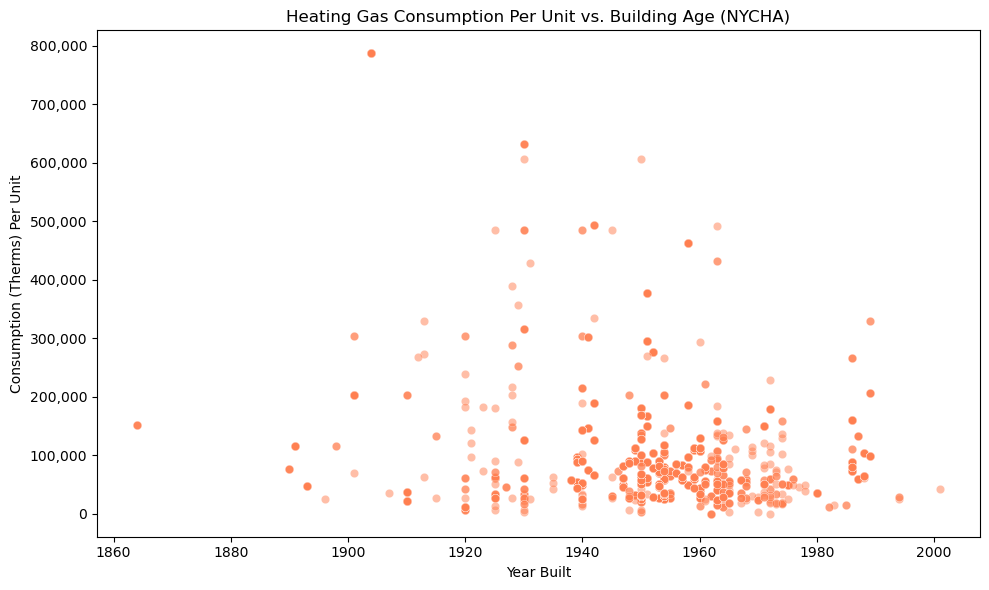

In [18]:
# Heating gas consumption per unit vs building age

fig, ax = plt.subplots(figsize=(10, 6))

scatter_df2 = final_gdf.dropna(subset=['yearbuilt', 'consumption_per_unit'])
scatter_df2 = scatter_df2[scatter_df2['yearbuilt'] > 0]  # drop placeholder 0s

ax.scatter(scatter_df2['yearbuilt'], scatter_df2['consumption_per_unit'],
           alpha=0.5, color='coral', edgecolors='white', linewidth=0.3)

ax.set_xlabel('Year Built')
ax.set_ylabel('Consumption (Therms) Per Unit')
ax.set_title('Heating Gas Consumption Per Unit vs. Building Age (NYCHA)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

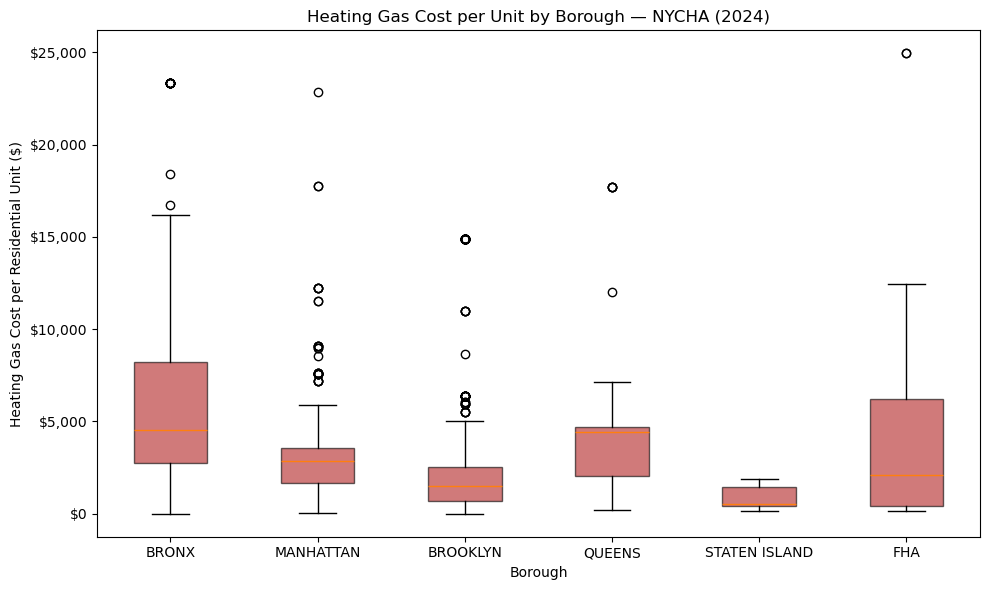

In [19]:
# Heating gas costs per unit by borough

heating_gas_cost_df_cleaned['revenue_month'] = pd.to_datetime(heating_gas_cost_df_cleaned['revenue_month'])
heating_gas_2024 = heating_gas_cost_df_cleaned[
    heating_gas_cost_df_cleaned['revenue_month'].dt.year == 2024
].copy()

# Clean and aggregate
heating_gas_2024['current_charges'] = (
    heating_gas_2024['current_charges']
    .astype(str)
    .str.replace('[$,]', '', regex=True)
    .str.strip()
)
heating_gas_2024['current_charges'] = pd.to_numeric(heating_gas_2024['current_charges'], errors='coerce')

heating_gas_agg_2024 = (
    heating_gas_2024
    .groupby('tds_#')
    .agg({
        'consumption_(therms)': 'sum',
        'current_charges': 'sum',
        'borough': 'first'
    })
    .reset_index()
)

heating_gas_agg_2024['tds_#'] = heating_gas_agg_2024['tds_#'].astype(str).str.strip()
combined_gdf['tds_#'] = combined_gdf['tds_#'].astype(str).str.strip()

final_gdf_2024 = combined_gdf.merge(heating_gas_agg_2024, on='tds_#', how='left')
final_gdf_2024['current_charges'] = pd.to_numeric(final_gdf_2024['current_charges'], errors='coerce')
final_gdf_2024['unitsres'] = pd.to_numeric(final_gdf_2024['unitsres'], errors='coerce')

# Calculate cost per unit
cost_per_unit_df = final_gdf_2024.dropna(subset=['current_charges', 'unitsres', 'borough']).copy()
cost_per_unit_df = cost_per_unit_df[cost_per_unit_df['unitsres'] > 0]
cost_per_unit_df['cost_per_unit'] = cost_per_unit_df['current_charges'] / cost_per_unit_df['unitsres']

# Build borough groups
borough_groups = {
    b: cost_per_unit_df[cost_per_unit_df['borough'] == b]['cost_per_unit'].dropna()
    for b in cost_per_unit_df['borough'].unique()
}
borough_groups = {k: v for k, v in borough_groups.items() if len(v) > 0}

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(borough_groups.values(), labels=borough_groups.keys(), patch_artist=True,
           boxprops=dict(facecolor='firebrick', alpha=0.6))
ax.set_xlabel('Borough')
ax.set_ylabel('Heating Gas Cost per Residential Unit ($)')
ax.set_title('Heating Gas Cost per Unit by Borough — NYCHA (2024)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

In [20]:
final_gdf.to_csv('../cleaned_data/combined_heating_gas_2024.csv', index=False)